In [2]:
import numpy as np
import pandas as pd
from sklearn.svm import SVC
import matplotlib.pyplot as plt 
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris
from pandas.plotting import scatter_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import learning_curve,GridSearchCV
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.model_selection import cross_val_score,StratifiedKFold,train_test_split

In [4]:
data=load_iris()
X=pd.DataFrame(data.data,columns=data.feature_names)
y=pd.Series(data.target,name="class")

df=X.copy()
df["class"]=y

display(df)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),class
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [6]:
print(df.describe())
print(df.info())
print(df["class"].value_counts())


       sepal length (cm)  sepal width (cm)  ...  petal width (cm)       class
count         150.000000        150.000000  ...        150.000000  150.000000
mean            5.843333          3.057333  ...          1.199333    1.000000
std             0.828066          0.435866  ...          0.762238    0.819232
min             4.300000          2.000000  ...          0.100000    0.000000
25%             5.100000          2.800000  ...          0.300000    0.000000
50%             5.800000          3.000000  ...          1.300000    1.000000
75%             6.400000          3.300000  ...          1.800000    2.000000
max             7.900000          4.400000  ...          2.500000    2.000000

[8 rows x 5 columns]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 

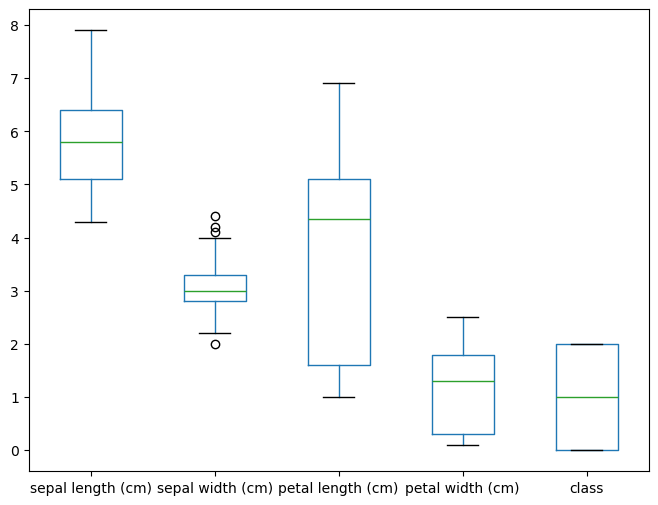

In [7]:
df.boxplot(figsize=(8,6),grid=False)
plt.show()

le feature petal lenght e sepal lenght hanno la maggiore evadibilità (hanno un interquartile più ampio), questo le rende molto buone per una discriminazione.
Ci sono degli outlier in sepal width e sono i punti fuori dai baffi. Potrebbero richiedere un ulteriore analisi o pulizia.
In generale la petal lenght  ha il range di valori più ampio, mentre sepal width e petal widht hanno valori più contenuti

ora facciamo un istrogramma

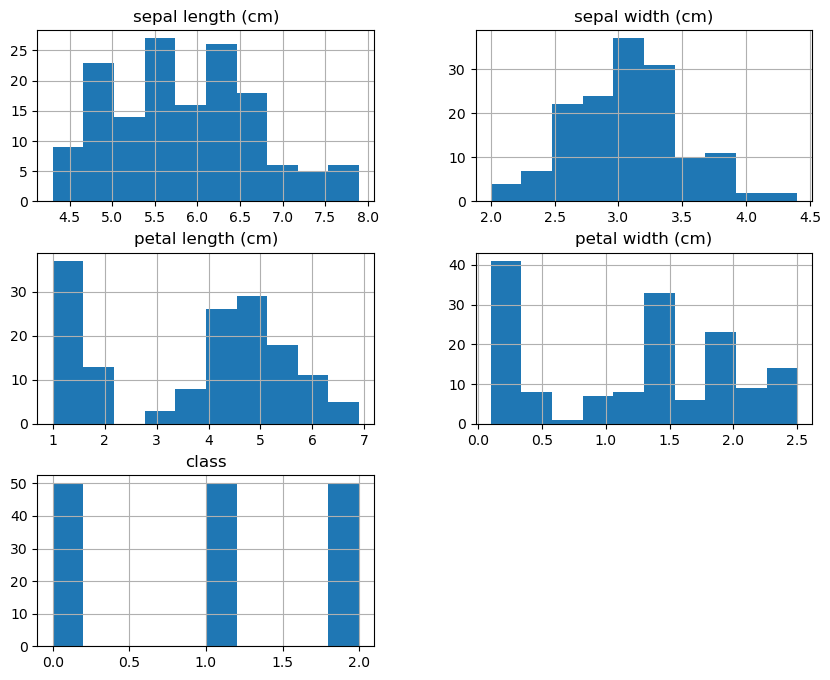

In [8]:
df.hist(figsize=(10,8))
plt.show()

abbiamo un istrogramma per ogni feature e per la classe.
La classe essendo 3 tipi di valori (0,1,2)è trivariata.
La sepal width segue una distribuzione a campana
La petal length è bimodale con due distribuzioni quasi a campana.
Idem per la petal width che è multimodale e sapel lenght

Ora faccio scattermatrix

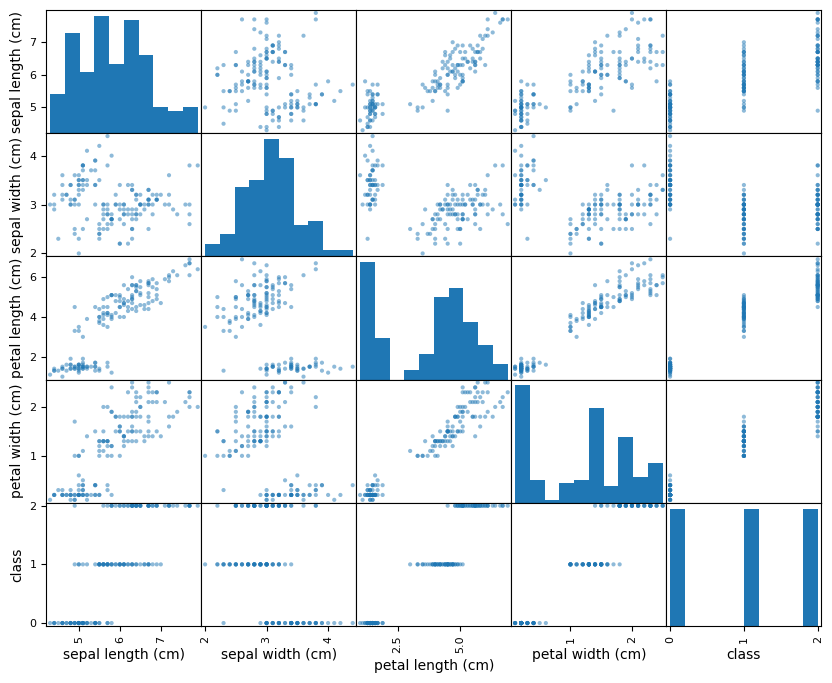

In [9]:
scatter_matrix(df,figsize=(10,8))
plt.show()

Lo scatter matrix mostra la relazione tra ogni coppia di variabili, tramite scatter plot e la distribuzione di ogni singola variabile tramite istogramma, che sono sulla diagonale principale.
Per quanto riguarda la petal lenght e width sono i migliori predittori, poiche sono strettamente correlati tra di loro e mostrano una separazione perfetta dalla classe 0
Per la sepal lenght e la sepal width si vede che sono meno utili, la correlazione tra questi due è debole e possono essere usati decentemente per fare una classificazione, ma si sovrappongono un pò di più per la classi 1 e 2. 
In generale il dataset è bilanciato (50 per ogni classe) e la distribuzione delle feature suggerisce dei gruppi distinti, quindi il problema sembra facilmente risolvibiile da un qualsiasi classificatore.


dividiamo il dataset tra train e test

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
